In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("disaster_impact_dataset.csv")

In [3]:
df.head()

,event_id,event_type,region,latitude,longitude,population_affected,pop_proxy,infrastructure_damage_score,vulnerability_index,economic_loss_kusd,fatalities,relief_funds_kusd,response_time_hrs,warning_issued,building_density
0,1,Cyclone,Highland,30.178080,82.118588,1205.0,629.0,0.00,-0.31,NaN,0,515.16,1.00,1,NaN
1,2,Flood,West,17.472510,71.111246,3443.0,2691.0,0.00,10.64,90.05,0,1388.91,9.43,1,50.16
2,3,Cyclone,West,21.928099,70.147195,5679.0,4788.0,6.89,11.43,481.97,0,0.00,NaN,0,53.93
3,4,Earthquake,East,24.773047,87.524908,2622.0,2677.0,0.00,19.09,127.37,0,NaN,6.76,1,50.02
4,5,Flood,Highland,26.889194,78.480015,4542.0,4039.0,17.52,20.71,994.28,0,551.42,7.84,1,55.96


In [7]:
df.shape

(12000, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   event_id                     12000 non-null  int64  
 1   event_type                   12000 non-null  object 
 2   region                       12000 non-null  object 
 3   latitude                     12000 non-null  float64
 4   longitude                    12000 non-null  float64
 5   population_affected          11280 non-null  float64
 6   pop_proxy                    12000 non-null  float64
 7   infrastructure_damage_score  11280 non-null  float64
 8   vulnerability_index          11280 non-null  float64
 9   economic_loss_kusd           11280 non-null  float64
 10  fatalities                   12000 non-null  int64  
 11  relief_funds_kusd            11280 non-null  float64
 12  response_time_hrs            11280 non-null  float64
 13  warning_issued  

In [11]:
df.describe()

,event_id,latitude,longitude,population_affected,pop_proxy,infrastructure_damage_score,vulnerability_index,economic_loss_kusd,fatalities,relief_funds_kusd,response_time_hrs,warning_issued,building_density
count,12000.00000,12000.000000,12000.000000,11280.000000,12000.000000,11280.000000,11280.000000,11280.000000,12000.000000,11280.00000,11280.000000,12000.000000,11280.000000
mean,6000.50000,21.058585,78.237581,11544.117376,11303.696167,4.916023,15.219684,571.261526,1.282083,433.13928,12.433103,0.565583,61.106734
std,3464.24595,6.675735,5.181092,22708.972593,22280.261767,7.010253,9.143634,1798.145757,9.392969,615.33139,13.626167,0.495701,24.105888
min,1.00000,6.704386,65.614486,30.000000,-1371.000000,0.000000,-10.580000,3.490000,0.000000,0.00000,1.000000,0.000000,5.000000
25%,3000.75000,15.113999,74.694613,2039.000000,2029.000000,0.000000,9.480000,138.297500,0.000000,0.00000,3.590000,0.000000,46.330000
50%,6000.50000,20.458156,77.485732,4884.500000,4831.000000,2.100000,14.310000,327.720000,0.000000,54.14500,8.620000,1.000000,58.210000
75%,9000.25000,27.855166,80.196376,11974.250000,11765.500000,7.970000,19.500000,666.600000,0.000000,741.69250,16.960000,1.000000,71.092500
max,12000.00000,34.958247,93.214851,434407.000000,426488.000000,97.480000,106.970000,150877.200208,330.000000,4048.68000,359.301393,1.000000,200.000000


In [13]:
df.isnull().sum()

event_id                         0
event_type                       0
region                           0
latitude                         0
longitude                        0
population_affected            720
pop_proxy                        0
infrastructure_damage_score    720
vulnerability_index            720
economic_loss_kusd             720
fatalities                       0
relief_funds_kusd              720
response_time_hrs              720
warning_issued                   0
building_density               720
dtype: int64

In [15]:
df.isnull().sum().sum()

5040

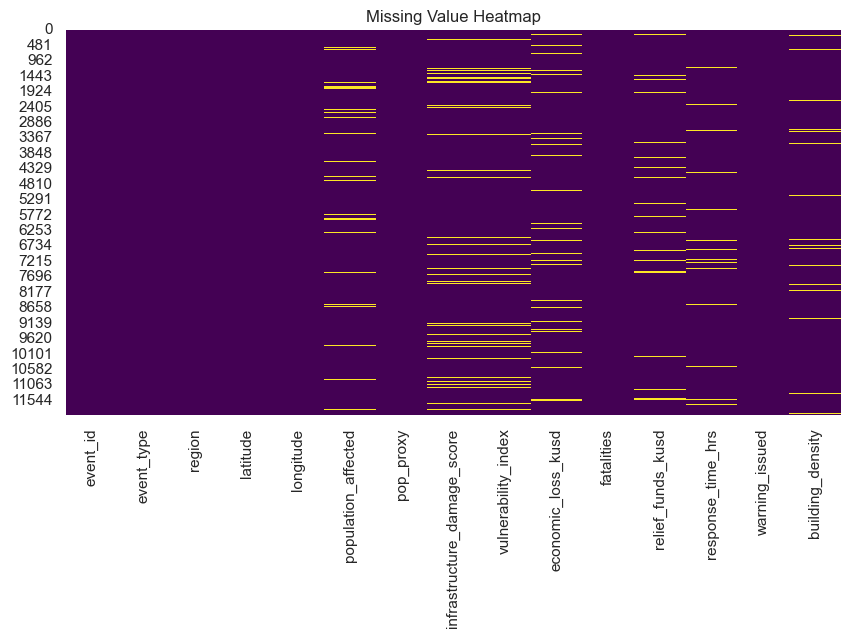

In [17]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

In [19]:
df.skew(numeric_only=True)

event_id                        0.000000
latitude                        0.074417
longitude                       0.722734
population_affected             7.315834
pop_proxy                       7.346979
infrastructure_damage_score     3.140032
vulnerability_index             1.890589
economic_loss_kusd             56.126598
fatalities                     19.948292
relief_funds_kusd               1.593443
response_time_hrs               5.196663
warning_issued                 -0.264653
building_density                1.918711
dtype: float64

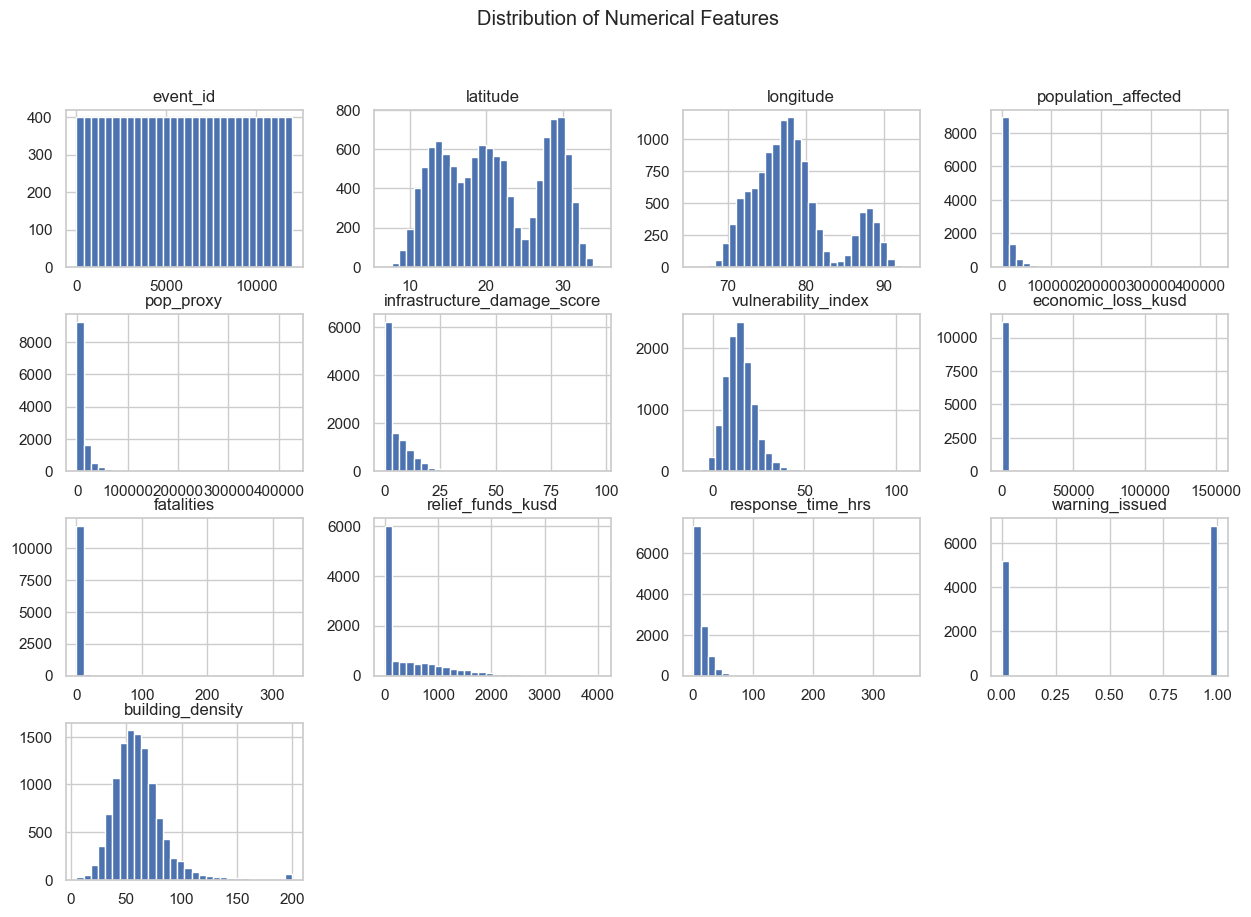

In [21]:
df.hist(figsize=(15,10), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

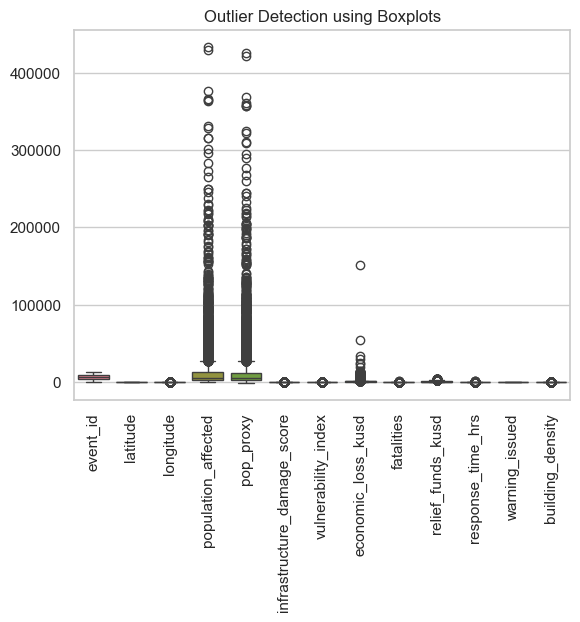

In [23]:
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Outlier Detection using Boxplots")
plt.show()

In [25]:
num_df = df.select_dtypes(include=[np.number])

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)

IQR = Q3 - Q1

outliers = ((num_df < (Q1 - 1.5 * IQR)) | 
            (num_df > (Q3 + 1.5 * IQR))).sum()
outliers

event_id                          0
latitude                          0
longitude                       715
population_affected            1108
pop_proxy                      1162
infrastructure_damage_score     325
vulnerability_index             303
economic_loss_kusd              672
fatalities                     2671
relief_funds_kusd               436
response_time_hrs               538
warning_issued                    0
building_density                413
dtype: int64

In [27]:
total_outliers = outliers.sum()
print("Total number of outliers:", total_outliers)

Total number of outliers: 8343


In [29]:
outlier_percent = (outliers / len(num_df)) * 100
outlier_percent.sort_values(ascending=False)

fatalities                     22.258333
pop_proxy                       9.683333
population_affected             9.233333
longitude                       5.958333
economic_loss_kusd              5.600000
response_time_hrs               4.483333
relief_funds_kusd               3.633333
building_density                3.441667
infrastructure_damage_score     2.708333
vulnerability_index             2.525000
event_id                        0.000000
latitude                        0.000000
warning_issued                  0.000000
dtype: float64

In [31]:
df['Total_Damage'] = (
    df['economic_loss_kusd'] +
    df['infrastructure_damage_score'] * 1000
)

In [33]:
print(list(df.columns))

['event_id', 'event_type', 'region', 'latitude', 'longitude', 'population_affected', 'pop_proxy', 'infrastructure_damage_score', 'vulnerability_index', 'economic_loss_kusd', 'fatalities', 'relief_funds_kusd', 'response_time_hrs', 'warning_issued', 'building_density', 'Total_Damage']


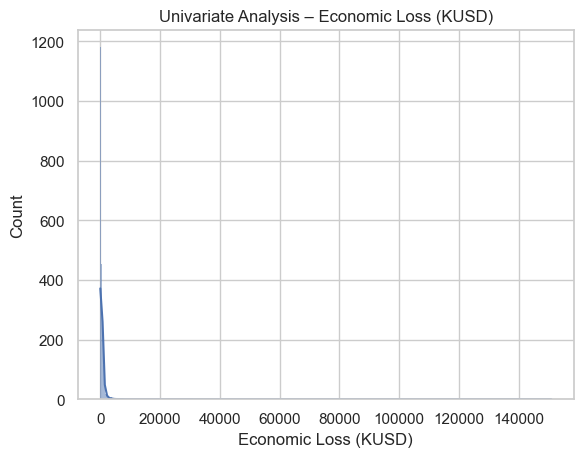

In [35]:
sns.histplot(df['economic_loss_kusd'], kde=True)
plt.title("Univariate Analysis – Economic Loss (KUSD)")
plt.xlabel("Economic Loss (KUSD)")
plt.show()

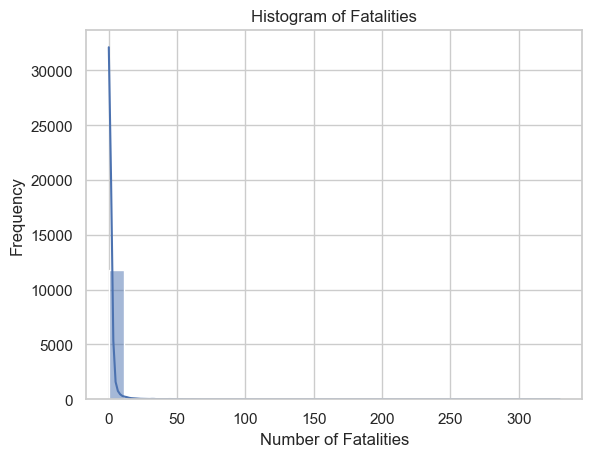

In [37]:
sns.histplot(df['fatalities'], bins=30, kde=True)
plt.title("Histogram of Fatalities")
plt.xlabel("Number of Fatalities")
plt.ylabel("Frequency")
plt.show()

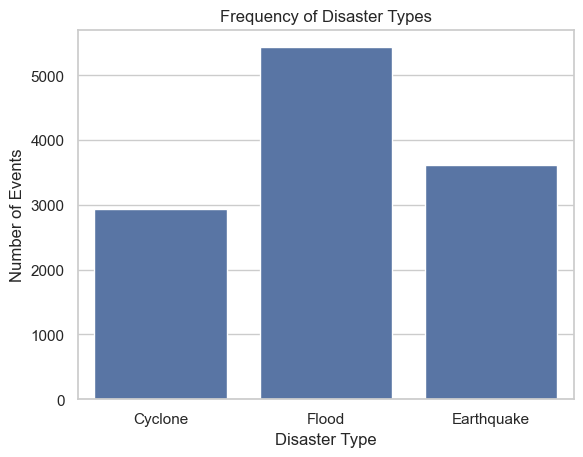

In [39]:
sns.countplot(x='event_type', data=df)
plt.title("Frequency of Disaster Types")
plt.xlabel("Disaster Type")
plt.ylabel("Number of Events")
plt.show()

In [41]:
print(list(df.columns))

['event_id', 'event_type', 'region', 'latitude', 'longitude', 'population_affected', 'pop_proxy', 'infrastructure_damage_score', 'vulnerability_index', 'economic_loss_kusd', 'fatalities', 'relief_funds_kusd', 'response_time_hrs', 'warning_issued', 'building_density', 'Total_Damage']


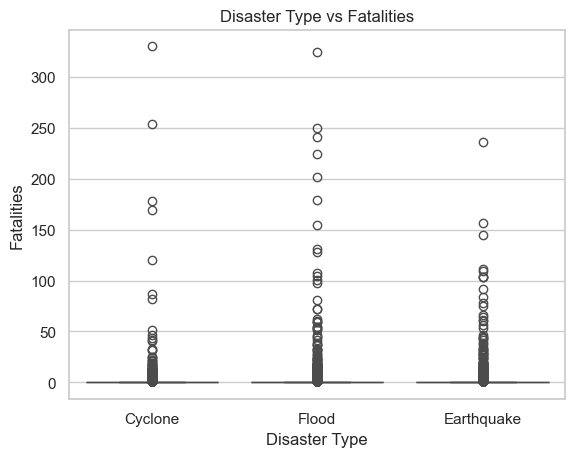

In [43]:
sns.boxplot(x='event_type', y='fatalities', data=df)
plt.title("Disaster Type vs Fatalities")
plt.xlabel("Disaster Type")
plt.ylabel("Fatalities")
plt.show()

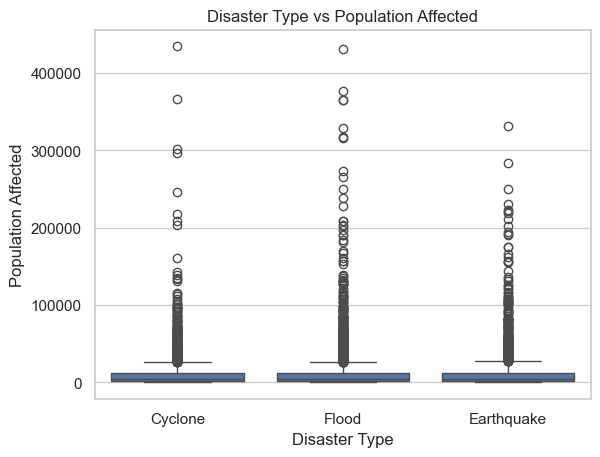

In [45]:
sns.boxplot(x='event_type', y='population_affected', data=df)

plt.title("Disaster Type vs Population Affected")
plt.xlabel("Disaster Type")
plt.ylabel("Population Affected")
plt.show()

In [47]:
df['Total_Damage'] = (
    df['economic_loss_kusd'] +
    df['infrastructure_damage_score'] * 1000
)

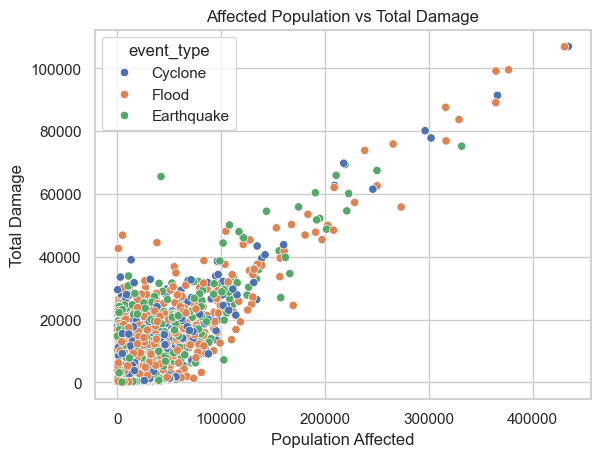

In [49]:
sns.scatterplot(
    x='population_affected',
    y='Total_Damage',
    hue='event_type',
    data=df
)
plt.title("Affected Population vs Total Damage")
plt.xlabel("Population Affected")
plt.ylabel("Total Damage")
plt.show()

In [51]:
print(list(df.columns))

['event_id', 'event_type', 'region', 'latitude', 'longitude', 'population_affected', 'pop_proxy', 'infrastructure_damage_score', 'vulnerability_index', 'economic_loss_kusd', 'fatalities', 'relief_funds_kusd', 'response_time_hrs', 'warning_issued', 'building_density', 'Total_Damage']


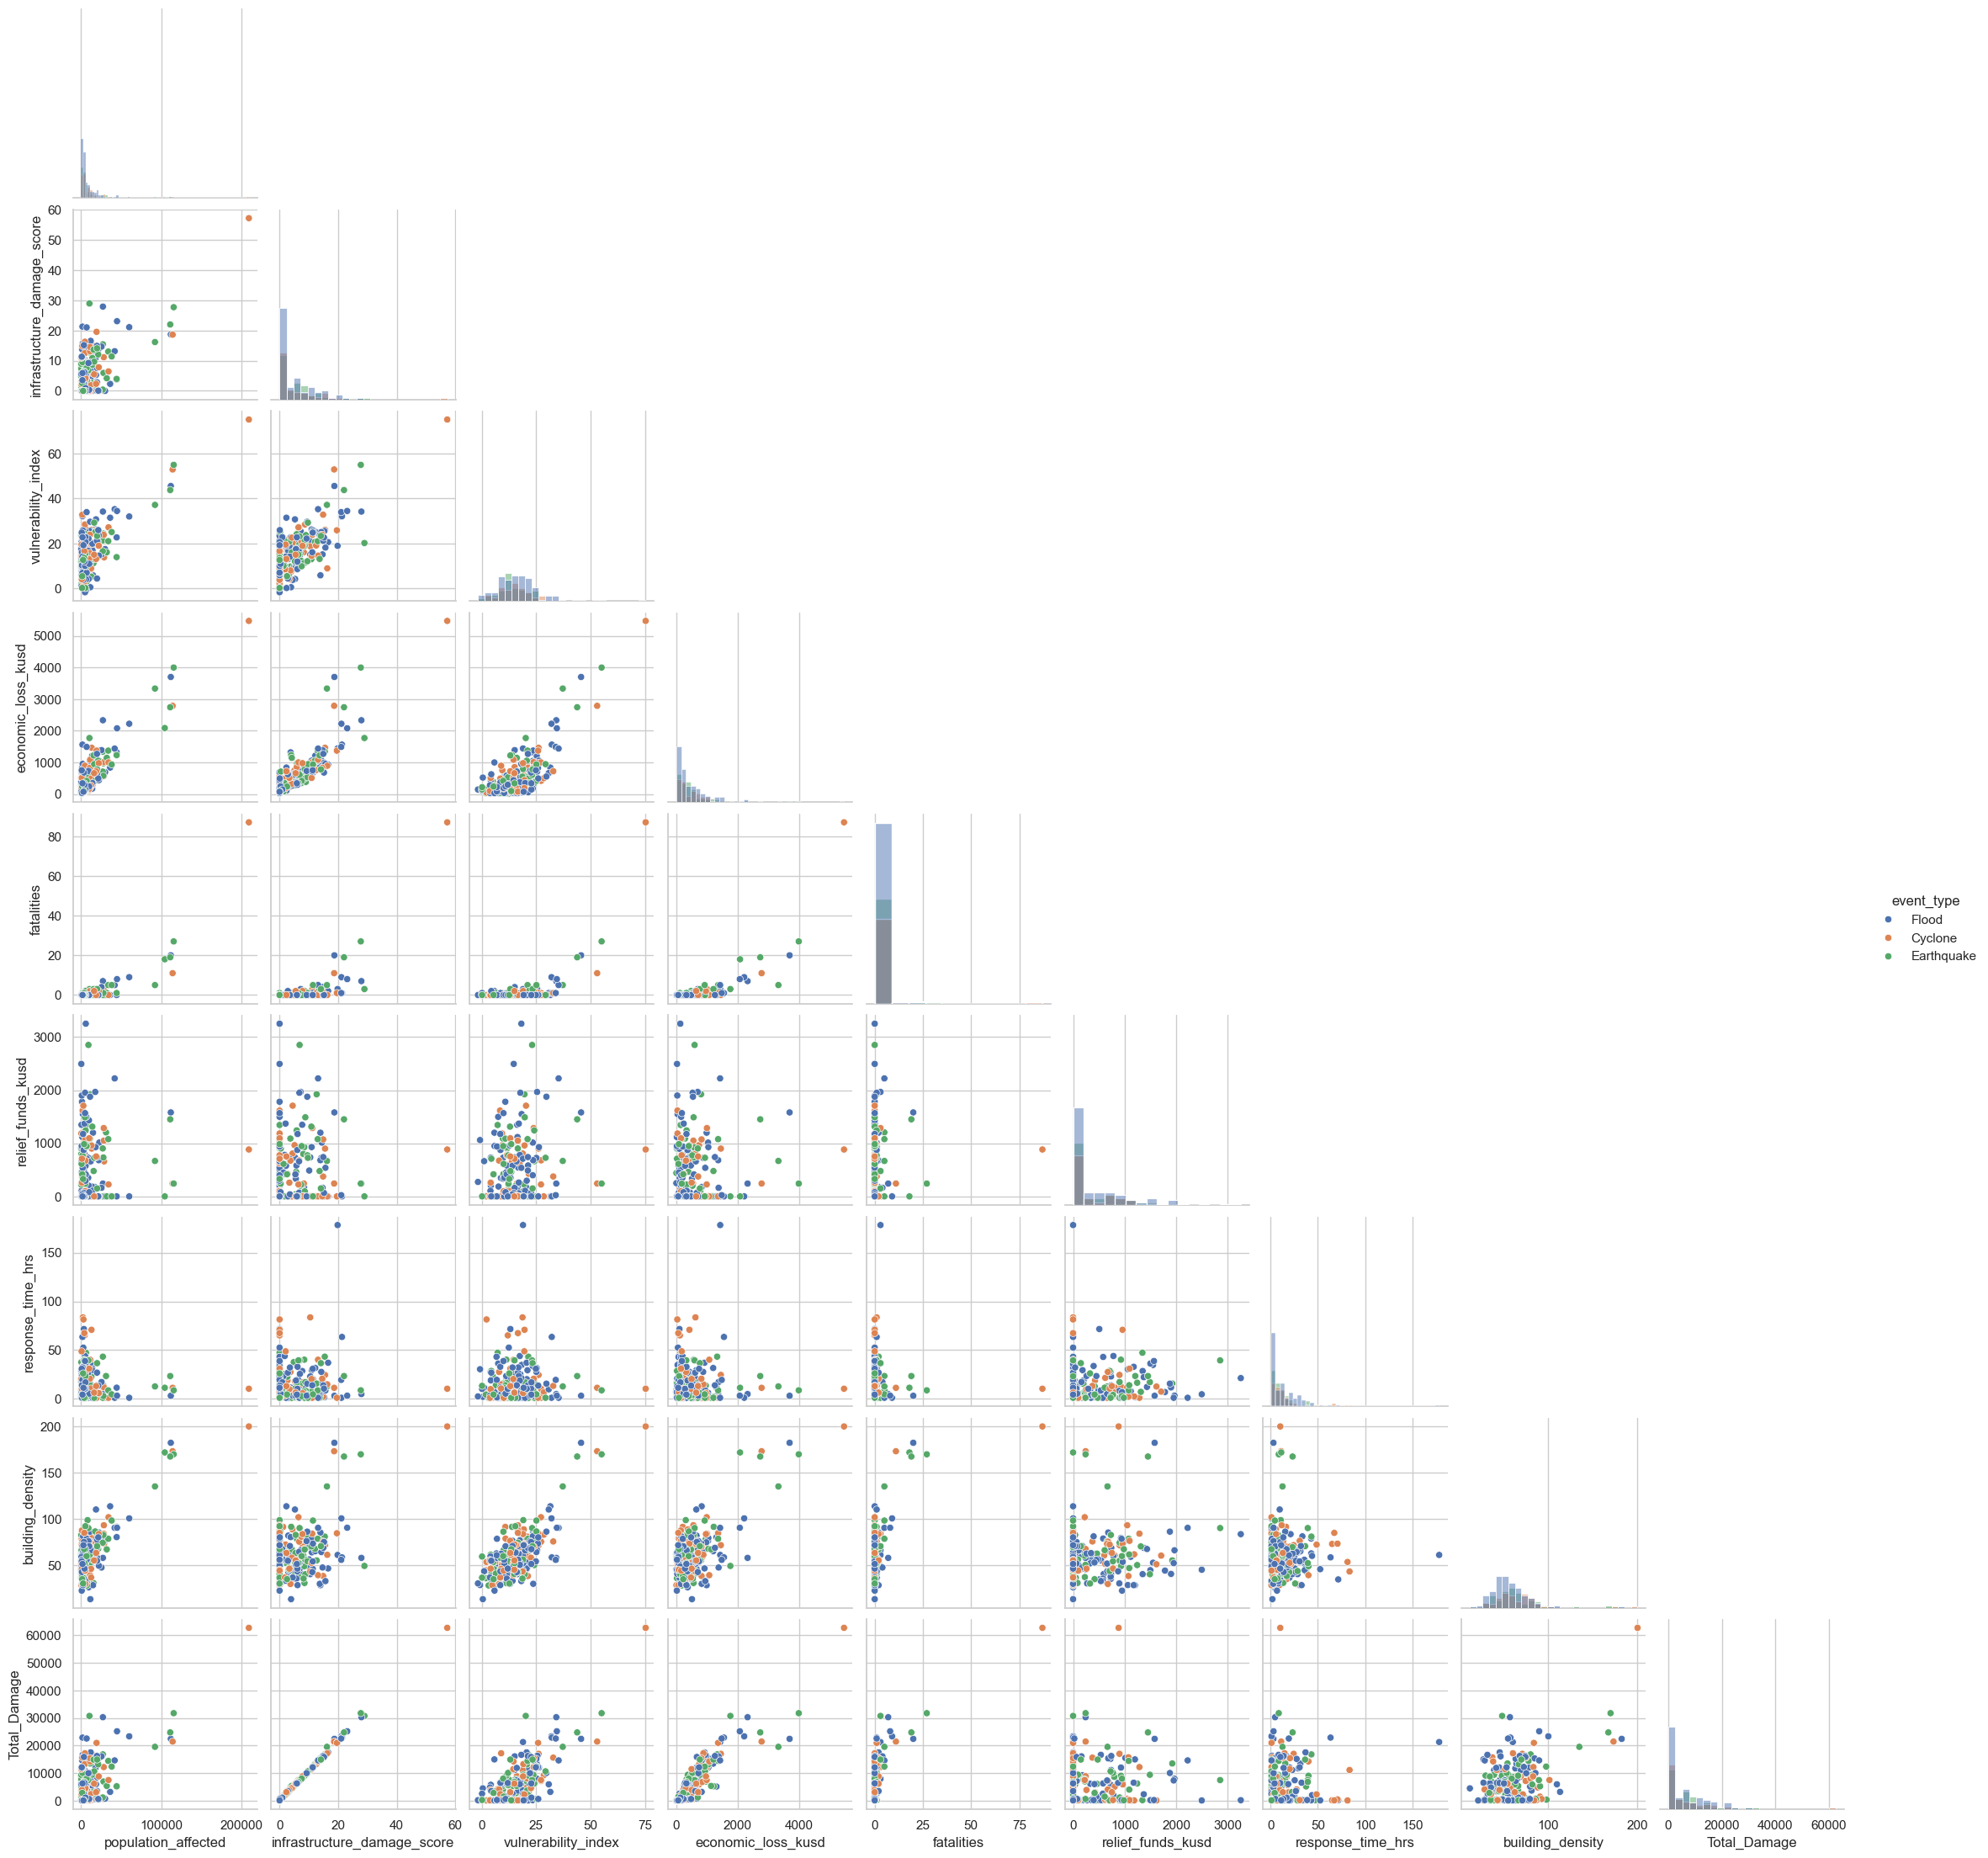

In [71]:
num_cols = [
    'population_affected',
    'infrastructure_damage_score',
    'vulnerability_index',
    'economic_loss_kusd',
    'fatalities',
    'relief_funds_kusd',
    'response_time_hrs',
    'building_density',
    'Total_Damage'
]
df_small = df[num_cols + ['event_type']].sample(
    n=min(300, len(df)),
    random_state=42
)

sns.pairplot(
    df_small,
    hue='event_type',
    diag_kind='hist',
    corner=True
)
plt.show()

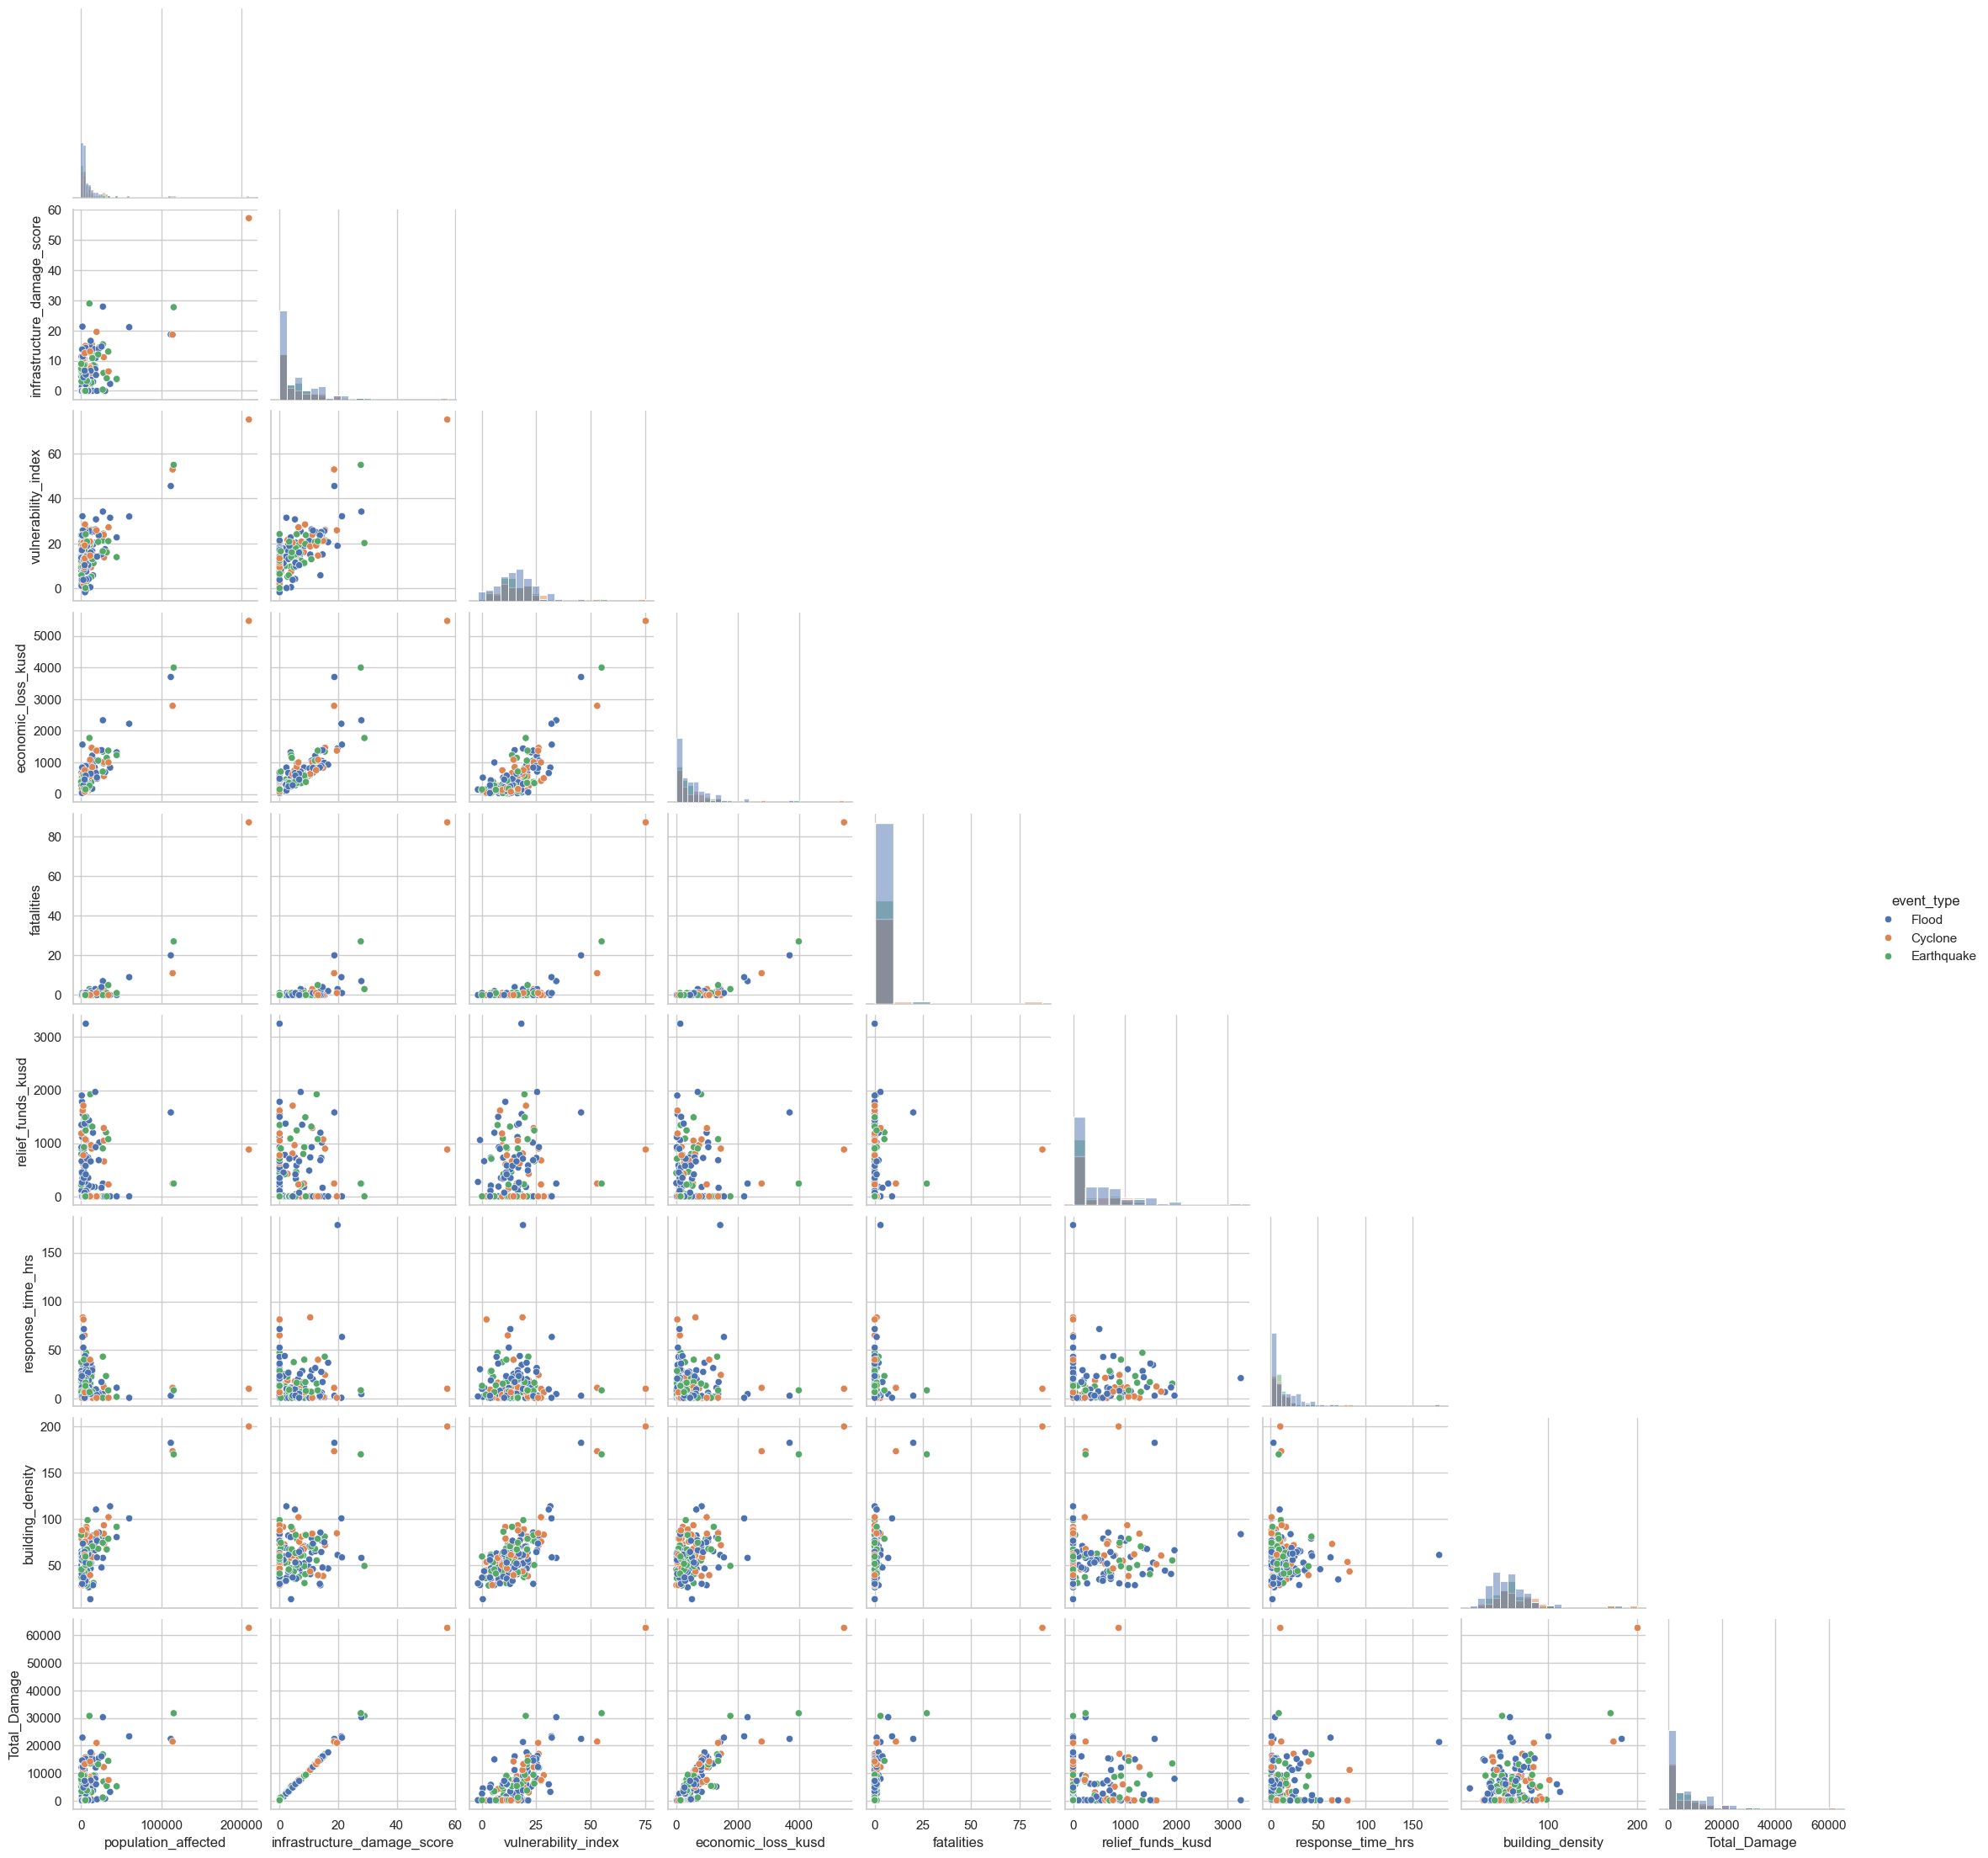

In [69]:
num_cols = [
    'population_affected',
    'infrastructure_damage_score',
    'vulnerability_index',
    'economic_loss_kusd',
    'fatalities',
    'relief_funds_kusd',
    'response_time_hrs',
    'building_density',
    'Total_Damage'
]

df_small = df[num_cols + ['event_type']].sample(
    n=min(200, len(df)),
    random_state=42
)

sns.pairplot(
    df_small,
    hue='event_type',
    diag_kind='hist',   
    corner=True       
)
plt.show()

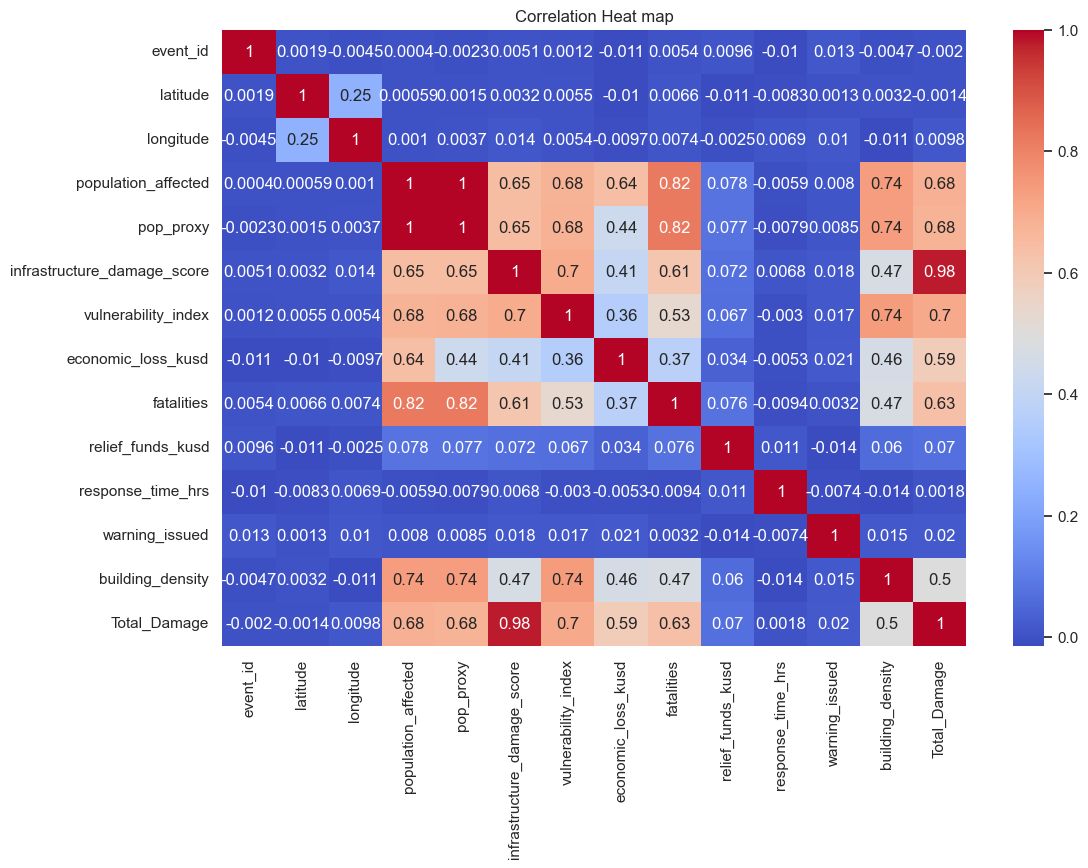

In [53]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heat map")
plt.show()


In [55]:
num_cols = df.select_dtypes(include=np.number).columns

X = df[num_cols].dropna()
X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif["Feature"] = X_const.columns
vif["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]
vif.sort_values("VIF", ascending=False)

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
6,infrastructure_damage_score,inf
8,economic_loss_kusd,inf
14,Total_Damage,inf
4,population_affected,2255.039426
5,pop_proxy,2248.992990
0,const,246.516036
9,fatalities,3.935936
13,building_density,3.596246
7,vulnerability_index,3.545446
3,longitude,1.064708


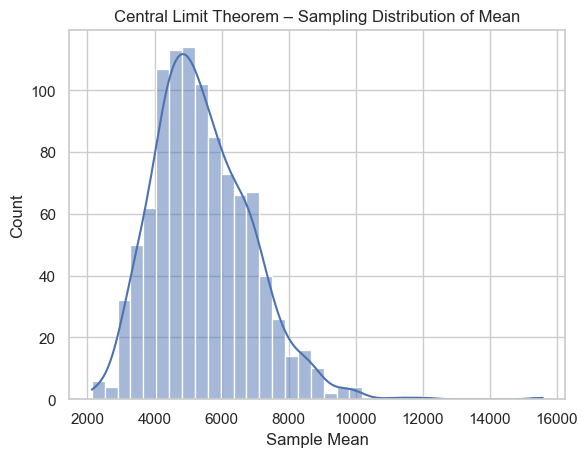

In [57]:
sample_means = []

for i in range(1000):
    sample = df['Total_Damage'].dropna().sample(30, replace=True)
    sample_means.append(sample.mean())

sns.histplot(sample_means, kde=True)
plt.title("Central Limit Theorem – Sampling Distribution of Mean")
plt.xlabel("Sample Mean")
plt.show()

In [59]:
stats.describe(df['Total_Damage'].dropna())

DescribeResult(nobs=10605, minmax=(3.49, 183907.20020820107), mean=5509.111443133849, variance=63828128.48443319, skewness=4.316145575619801, kurtosis=46.00926183798918)

In [61]:
from scipy.stats import shapiro

flood_damage = df[df['event_type'] == 'Flood']['Total_Damage'].dropna()
earthquake_damage = df[df['event_type'] == 'Earthquake']['Total_Damage'].dropna()

shapiro(flood_damage)
shapiro(earthquake_damage)

ShapiroResult(statistic=0.713284732125596, pvalue=4.935987277296482e-59)

In [63]:
from scipy.stats import levene

levene(flood_damage, earthquake_damage)

LeveneResult(statistic=2.09371877344329, pvalue=0.14794495444332995)

In [65]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    flood_damage,
    earthquake_damage,
    equal_var=False  
)
t_stat, p_value

(-1.145132040858716, 0.25219483714869567)

In [67]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis (Significant difference exists).")
else:
    print("Fail to reject the null hypothesis (No significant difference).")

Fail to reject the null hypothesis (No significant difference).
